In [2]:
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

# Load data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()

In [3]:
# Initialize and train
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# Save model
joblib.dump(model, '../models/baseline_logistic_model.pkl')

['../models/baseline_logistic_model.pkl']

In [4]:
baseline_metrics = {
    'model_name': 'Logistic Regression (Baseline)',
    'accuracy': accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred),
    'recall': recall_score(y_val, y_pred),
    'f1_score': f1_score(y_val, y_pred),
    'roc_auc': roc_auc_score(y_val, y_prob)
}

print(json.dumps(baseline_metrics, indent=4))

with open('../models/baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=4)

{
    "model_name": "Logistic Regression (Baseline)",
    "accuracy": 0.7260981912144703,
    "precision": 0.5263157894736842,
    "recall": 0.18518518518518517,
    "f1_score": 0.273972602739726,
    "roc_auc": 0.7553763440860215
}


<Figure size 800x600 with 0 Axes>

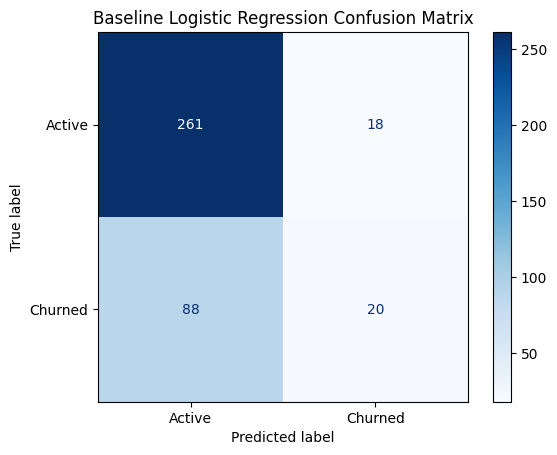

In [5]:
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Baseline Logistic Regression Confusion Matrix')
plt.savefig('../visualizations/baseline_confusion_matrix.png')
plt.show()

{'model_name': 'Logistic Regression (Baseline)', 'accuracy': 0.7260981912144703, 'precision': 0.5263157894736842, 'recall': 0.18518518518518517, 'f1_score': 0.273972602739726, 'roc_auc': 0.7553763440860215}


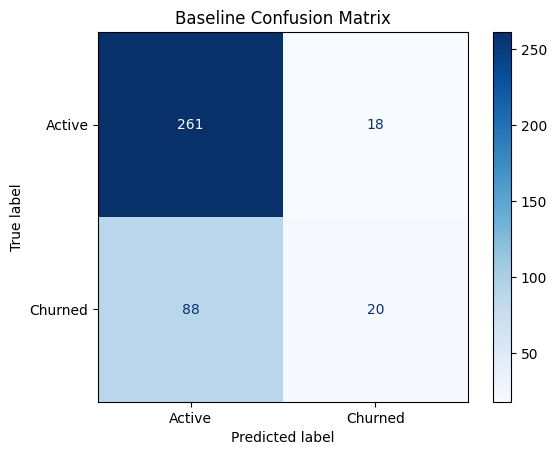

In [6]:
# --- Section 1: Load Prepared Data ---
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()

# --- Section 2: Build Logistic Regression ---
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# Save Model
joblib.dump(model, '../models/baseline_logistic_model.pkl')

# --- Section 3: Baseline Performance ---
baseline_metrics = {
    'model_name': 'Logistic Regression (Baseline)',
    'accuracy': accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred),
    'recall': recall_score(y_val, y_pred),
    'f1_score': f1_score(y_val, y_pred),
    'roc_auc': roc_auc_score(y_val, y_prob)
}

with open('../models/baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=4)
print(baseline_metrics)

# --- Section 4: Visualize Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.savefig('../visualizations/baseline_confusion_matrix.png')
plt.show()